# **Evaluation – Methodenvergleich für die Fahrbahnoberflächen-Erkennung**

Dieses Notebook vergleicht mehrere **trainingsfreie (Zero-Shot)** Methoden zur Klassifikation der
**Fahrbahnoberfläche** und bewertet sie quantitativ gegen den **manuell gelabelten Testdatensatz**
aus [`label_data.ipynb`](./label_data.ipynb) (`evaluate/labels_testdataset.csv`).

**Zielmetriken:**

- **Accuracy** – Anteil korrekt klassifizierter Bilder.
- **Balanced Accuracy** – Mittelwert der klassenweisen Recalls (wichtig, da der Datensatz stark
  unbalanciert ist: Asphalt dominiert, Erde/Schotter selten).
- **Macro-F1** – ungewichteter Mittelwert der klassenweisen F1-Scores.
- **Latenz** – Inferenzzeit pro Bild (ms/Bild) sowie Durchsatz (Bilder/s) und Modellgröße
  (Parameter). Entscheidend für den späteren Einsatz auf vielen Frames.

## Methodik & faire Vergleichsbasis

Ein zentraler Punkt: **Semantische Segmentierung** (SegFormer, *Cityscapes*) und
**YOLO-Segmentierung** (COCO) liefern von sich aus **keine Oberflächen-Materialklasse** –
sie erkennen nur die Region *Straße* bzw. Objekte (Autos, Personen …), nicht *Asphalt vs.
Kopfsteinpflaster*. Ohne eigenes Training kann die eigentliche **Material-Klassifikation** nur ein
**Vision-Language-Modell (VLM)** wie CLIP leisten, das Bild und Textbeschreibung im gemeinsamen
Vektorraum vergleicht.

Daher evaluieren wir zwei Ebenen:

1. **Reiner Vision-Modell-Vergleich (Vollbild):** bis zu **5 leichtgewichtige/starke VLMs**
   (OpenAI-CLIP-Varianten, LAION-CLIP, SigLIP) klassifizieren das gesamte Bild per Zero-Shot.
2. **Vorverarbeitung durch Segmentierung:** dasselbe repräsentative VLM wird mit verschiedenen
   **ROI-Extraktoren** kombiniert, um zu messen, ob das Isolieren der Fahrbahn die Genauigkeit
   erhöht – und zu welchem Latenz-Preis:
   - **Vollbild** (Referenz, keine Vorverarbeitung),
   - **Fixe ROI** (unterer, mittiger Bildausschnitt, vgl. [`ground_detection.ipynb`](../research/ground_detection.ipynb)),
   - **Semantische Segmentierung** (SegFormer-Straßenmaske, vgl. [`ground_detection_with_cropped_frames.ipynb`](../research/ground_detection_with_cropped_frames.ipynb)),
   - **YOLO-Segmentierung** (Entfernen von Vordergrundobjekten aus der ROI).

So beantwortet die Auswertung sowohl *„welches Vision-Modell ist am besten?"* als auch
*„bringt Segmentierung als Vorverarbeitung einen Mehrwert?"* – jeweils mit Accuracy **und** Latenz.

**Ablauf:** Setup → Konfiguration → Ground Truth laden → Metrik-/Benchmark-Utilities →
VLM-Wrapper & ROI-Extraktoren → Benchmark ausführen → Ergebnistabelle, Diagramme,
Konfusionsmatrizen → Empfehlung.


## 1. Setup & Imports

Wir nutzen `transformers` (CLIP- und SigLIP-VLMs sowie SegFormer), `ultralytics` (YOLO-Segmentierung),
`torch`, `opencv`, `pandas` und `matplotlib`. Modellgewichte werden beim ersten Aufruf automatisch
heruntergeladen und lokal zwischengespeichert. Eine CUDA-GPU wird automatisch genutzt und
beschleunigt die Auswertung erheblich.


In [1]:
# Einmalige Installation (nur beim ersten Mal nötig) – Kommentar entfernen und ausführen:
# %pip install torch transformers ultralytics opencv-python pillow numpy pandas matplotlib

from __future__ import annotations

import csv
import gc
import time
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import AutoImageProcessor, AutoModel, AutoProcessor

warnings.filterwarnings("ignore")  # HF/Ultralytics-Hinweise ausblenden

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch-Version: {torch.__version__}")
print(f"Rechengerät (Device): {DEVICE}")
if DEVICE == "cpu":
    print("Hinweis: Ohne GPU kann der Benchmark einige Minuten dauern "
          "(ggf. PER_CLASS_CAP niedrig halten).")


PyTorch-Version: 2.6.0+cpu
Rechengerät (Device): cpu
Hinweis: Ohne GPU kann der Benchmark einige Minuten dauern (ggf. PER_CLASS_CAP niedrig halten).


## 2. Konfiguration

Pfade, Oberflächen-Klassen mit CLIP-Prompts (identisch zu `ground_detection.ipynb`), die fixe ROI
und Evaluations-Optionen.

- **Bewertete Klassen:** die vier eindeutigen Oberflächen. Die Label-Klasse *Unklar/Sonstige* wird
  aus der Evaluation ausgeschlossen (mehrdeutige Ground Truth, keine sinnvolle Textbeschreibung).
- **Vision-Modelle:** bis zu 5 VLMs von leichtgewichtig (CLIP-B/32) bis stark (CLIP-L/14, SigLIP).
- **`PER_CLASS_CAP`:** begrenzt die Bilder je Klasse für einen schnelleren Durchlauf und wirkt der
  starken Klassen-Unbalance entgegen (seltene Klassen bleiben vollständig). `None` = alle Bilder.


In [2]:
# --- Pfade (Notebook liegt in evaluate/) ---
TESTDATASET_DIR = Path("../dataset/testdataset")
LABELS_CSV = Path("labels_testdataset.csv")
RESULTS_CSV = Path("evaluation_results.csv")

# --- Oberflächen-Klassen + CLIP-Prompts (konsistent zu ground_detection.ipynb) ---
SURFACE_CLASSES: dict[str, list[str]] = {
    "Asphalt/Beton": [
        "a photo of a smooth asphalt road surface",
        "a tarmac bike path",
        "black asphalt pavement",
        "a photo of a concrete road surface",
        "a smooth concrete pavement",
    ],
    "Pflaster/Kopfsteinpflaster": [
        "a photo of a road paved with rectangular paving stones",
        "interlocking concrete block paving",
        "a brick paved path",
        "a photo of a cobblestone street",
        "a rough cobbled road with round stones",
        "an old cobblestone pavement",
    ],
    "Schotter/Kies": [
        "a photo of a gravel road",
        "a path covered with loose gravel and small stones",
        "a crushed stone gravel track",
    ],
    "Erde/Feldweg": [
        "a photo of a dirt road made of bare soil",
        "an unpaved earth field path",
        "a muddy dirt track",
    ],
}
EVAL_CLASSES = list(SURFACE_CLASSES)          # bewertete Klassen (ohne "Unklar/Sonstige")
EXCLUDE_LABELS = {"Unklar/Sonstige"}          # aus der Evaluation ausgeschlossen

# Flache Prompt-Liste + Zuordnung Prompt-Index -> Klasse
PROMPTS: list[str] = []
PROMPT_CLASS_IDX: dict[str, list[int]] = defaultdict(list)
for cls_name, cls_prompts in SURFACE_CLASSES.items():
    for prompt in cls_prompts:
        PROMPT_CLASS_IDX[cls_name].append(len(PROMPTS))
        PROMPTS.append(prompt)

# --- Fixe Fahrbahn-ROI (Anteile der Bildhöhe/-breite) ---
ROI_TOP, ROI_BOTTOM = 0.62, 0.98
ROI_LEFT, ROI_RIGHT = 0.28, 0.72

# --- Vision-Modelle (max. 5) – alle Zero-Shot via transformers ---
VLM_MODELS = [
    "openai/clip-vit-base-patch32",                 # leichtgewichtige Referenz
    "openai/clip-vit-base-patch16",                 # etwas stärker, ähnlich schnell
    "openai/clip-vit-large-patch14",                # stark, aber deutlich langsamer
    "laion/CLIP-ViT-B-32-laion2B-s34B-b79K",        # OpenCLIP/LAION-Training
    "google/siglip-base-patch16-224",               # SigLIP: effizient & stark
]
# Repräsentatives VLM für den Segmentierungs-/ROI-Vergleich (schnell & solide)
REPRESENTATIVE_VLM = "openai/clip-vit-base-patch32"

# Segmentierungsmodelle
SEG_MODEL_NAME = "nvidia/segformer-b5-finetuned-cityscapes-1024-1024"
ROAD_CLASS_ID = 0          # Cityscapes-Train-ID der Klasse 'road'
MIN_ROAD_RATIO = 0.02      # Mindestanteil Straßen-Pixel, sonst Fallback auf fixe ROI
YOLO_SEG_MODEL = "yolo11n-seg.pt"   # leichtes YOLO-Segmentierungsmodell (Auto-Download)

# --- Selbstüberwachtes Modell (DINOv2) – kein Textencoder, daher k-NN-Klassifikation ---
DINO_MODELS = [
    "facebook/dinov2-small",    # leichtgewichtig (~22M Params)
    "facebook/dinov2-base",     # stärker (~86M Params)
]
DINO_KNN_K = 5             # Anzahl Nachbarn für die k-NN-Abstimmung (Leave-One-Out)

# --- Evaluations-Optionen ---
PER_CLASS_CAP = None       # max. Bilder je Klasse (None = alle); dämpft Unbalance & Laufzeit
RANDOM_SEED = 42

print(f"Bewertete Klassen: {EVAL_CLASSES}")
print(f"Anzahl Prompts   : {len(PROMPTS)}")
print(f"Vision-Modelle   : {len(VLM_MODELS)}")
print(f"DINOv2-Modelle   : {len(DINO_MODELS)}")
print(f"PER_CLASS_CAP    : {PER_CLASS_CAP}")


Bewertete Klassen: ['Asphalt/Beton', 'Pflaster/Kopfsteinpflaster', 'Schotter/Kies', 'Erde/Feldweg']
Anzahl Prompts   : 17
Vision-Modelle   : 5
DINOv2-Modelle   : 2
PER_CLASS_CAP    : None


## 3. Ground Truth laden & Evaluationsmenge zusammenstellen

Wir lesen die gelabelte CSV, behalten nur Bilder mit einer der vier bewerteten Klassen, die auch
tatsächlich als Datei vorliegen, und ziehen – sofern `PER_CLASS_CAP` gesetzt ist – eine
**stratifizierte Teilmenge** (seltene Klassen bleiben vollständig). Das Ergebnis ist die Liste
`EVAL_ITEMS` mit `(Dateiname, Pfad, Ground-Truth-Klasse)`.


In [3]:
def load_ground_truth(csv_path: Path) -> list[tuple[str, Path, str]]:
    """Liest die Label-CSV und liefert (Dateiname, Pfad, Klasse) für vorhandene Bilder."""
    items: list[tuple[str, Path, str]] = []
    missing = 0
    with csv_path.open(newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            label = row["label"]
            if label in EXCLUDE_LABELS:
                continue
            path = TESTDATASET_DIR / row["filename"]
            if not path.exists():
                missing += 1
                continue
            items.append((row["filename"], path, label))
    if missing:
        print(f"Hinweis: {missing} gelabelte Bilder fehlen im Ordner und werden übersprungen.")
    return items


def stratified_subset(
    items: list[tuple[str, Path, str]], cap: int | None, seed: int
) -> list[tuple[str, Path, str]]:
    """Begrenzt die Bildanzahl je Klasse auf `cap` (seltene Klassen bleiben vollständig)."""
    if cap is None:
        return items
    rng = np.random.default_rng(seed)
    by_class: dict[str, list] = defaultdict(list)
    for it in items:
        by_class[it[2]].append(it)
    subset: list = []
    for cls, group in by_class.items():
        if len(group) > cap:
            idx = rng.choice(len(group), size=cap, replace=False)
            group = [group[i] for i in sorted(idx)]
        subset.extend(group)
    return subset


all_items = load_ground_truth(LABELS_CSV)
EVAL_ITEMS = stratified_subset(all_items, PER_CLASS_CAP, RANDOM_SEED)
GT_LABELS = [gt for _, _, gt in EVAL_ITEMS]

print(f"Gelabelte, verfügbare Bilder (ohne {EXCLUDE_LABELS}): {len(all_items)}")
print(f"Evaluationsmenge nach Stratifizierung            : {len(EVAL_ITEMS)}")
print("\nKlassenverteilung der Evaluationsmenge:")
for cls in EVAL_CLASSES:
    print(f"  {cls:<28}{Counter(GT_LABELS)[cls]:>4}")

if not EVAL_ITEMS:
    print("\n⚠ Keine Evaluationsbilder gefunden – bitte zuerst in label_data.ipynb labeln.")


Gelabelte, verfügbare Bilder (ohne {'Unklar/Sonstige'}): 420
Evaluationsmenge nach Stratifizierung            : 420

Klassenverteilung der Evaluationsmenge:
  Asphalt/Beton                354
  Pflaster/Kopfsteinpflaster    45
  Schotter/Kies                 16
  Erde/Feldweg                   5


## 4. Metriken & Benchmark-Utilities

Wir implementieren die Metriken bewusst selbst (keine zusätzliche Abhängigkeit): **Accuracy**,
**Balanced Accuracy** (Mittel der klassenweisen Recalls), **Macro-F1** und die **Konfusionsmatrix**.
`run_method` misst zusätzlich die **Latenz pro Bild** (mit GPU-Synchronisation und Warmup) und
sammelt Vorhersagen sowie Timing-Statistiken für jede Methode.


In [4]:
def compute_metrics(gt: list[str], pred: list[str], classes: list[str]) -> dict:
    """Berechnet Accuracy, Balanced Accuracy, Macro-F1, klassenweise PRF und Konfusionsmatrix."""
    idx = {c: i for i, c in enumerate(classes)}
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    for g, p in zip(gt, pred):
        if g in idx and p in idx:
            cm[idx[g], idx[p]] += 1

    per_class, recalls, f1s = {}, [], []
    for c in classes:
        i = idx[c]
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        per_class[c] = {"precision": precision, "recall": recall,
                        "f1": f1, "support": int(cm[i, :].sum())}
        recalls.append(recall)
        f1s.append(f1)

    total = cm.sum()
    accuracy = np.trace(cm) / total if total else 0.0
    return {
        "accuracy": float(accuracy),
        "balanced_accuracy": float(np.mean(recalls)),
        "macro_f1": float(np.mean(f1s)),
        "per_class": per_class,
        "confusion": cm,
    }


def _sync() -> None:
    """Synchronisiert die GPU für korrekte Zeitmessung (No-op auf CPU)."""
    if DEVICE == "cuda":
        torch.cuda.synchronize()


def load_image(path: Path) -> Image.Image:
    """Lädt ein Bild als RGB-PIL-Image."""
    return Image.open(path).convert("RGB")


def run_method(name: str, predict_fn, eval_items: list[tuple[str, Path, str]]) -> dict:
    """Führt eine Methode über die Evaluationsmenge aus und misst Vorhersagen + Latenz.

    `predict_fn(pil_image) -> Klassenname`. Rückgabe: Dict mit Metriken und Timing.
    """
    # Warmup (nicht gemessen), um Lazy-Init/Kernel-Kompilierung auszuschließen
    predict_fn(load_image(eval_items[0][1]))

    preds: list[str] = []
    latencies_ms: list[float] = []
    for _fname, path, _gt in eval_items:
        image = load_image(path)
        _sync()
        t0 = time.perf_counter()
        pred = predict_fn(image)
        _sync()
        latencies_ms.append((time.perf_counter() - t0) * 1000.0)
        preds.append(pred)

    metrics = compute_metrics([gt for _, _, gt in eval_items], preds, EVAL_CLASSES)
    lat = np.array(latencies_ms)
    result = {
        "method": name,
        "predictions": preds,
        "latencies_ms": latencies_ms,
        "latency_mean_ms": float(lat.mean()),
        "latency_p50_ms": float(np.percentile(lat, 50)),
        "latency_p95_ms": float(np.percentile(lat, 95)),
        "throughput_ips": float(1000.0 / lat.mean()) if lat.mean() else 0.0,
        **metrics,
    }
    print(f"  ✓ {name:<38} acc={result['accuracy']:.3f}  "
          f"bal_acc={result['balanced_accuracy']:.3f}  macroF1={result['macro_f1']:.3f}  "
          f"{result['latency_mean_ms']:.1f} ms/Bild")
    return result


print("Metrik- und Benchmark-Utilities definiert.")


Metrik- und Benchmark-Utilities definiert.


## 5. Vision-Language-Modell (VLM) & ROI-Extraktoren

`ZeroShotVLM` kapselt ein beliebiges CLIP-/SigLIP-Modell aus `transformers`: Es berechnet einmalig
die (normalisierten) Text-Embeddings aller Prompts und klassifiziert dann ein Bild per
Kosinus-Ähnlichkeit (stärkster Prompt je Klasse → argmax). Die einheitliche
`get_text_features`/`get_image_features`-API funktioniert für CLIP **und** SigLIP.

Die **ROI-Extraktoren** liefern jeweils den zu klassifizierenden Bildausschnitt als PIL-Image:

- `extract_full` – ganzes Bild.
- `extract_roi` – fixe untere, mittige ROI.
- `extract_segformer` – SegFormer-Straßenmaske, auf die Bounding-Box zugeschnitten (Fallback: ROI).
- `extract_yolo` – YOLO-Segmentierung entfernt Vordergrundobjekte (Autos, Personen …) aus der ROI.

SegFormer und YOLO werden **lazy** (erst bei Bedarf) geladen.


In [5]:
class ZeroShotVLM:
    """Zero-Shot-Klassifikator auf Basis eines CLIP-/SigLIP-Modells aus transformers."""

    def __init__(self, model_name: str, device: str = DEVICE):
        self.name = model_name
        self.device = device
        self.model = AutoModel.from_pretrained(model_name).to(device).eval()
        self.processor = AutoProcessor.from_pretrained(model_name)
        self.num_params = sum(p.numel() for p in self.model.parameters())

        # Text-Embeddings der Prompts einmalig berechnen und normalisieren
        with torch.no_grad():
            text_inputs = self.processor(
                text=PROMPTS, return_tensors="pt", padding="max_length", truncation=True
            ).to(device)
            tf = self.model.get_text_features(**text_inputs)
            self.text_features = tf / tf.norm(dim=-1, keepdim=True)

    @torch.no_grad()
    def classify(self, pil_image: Image.Image) -> str:
        """Liefert den wahrscheinlichsten Oberflächen-Klassennamen für ein Bild."""
        img_inputs = self.processor(images=pil_image, return_tensors="pt").to(self.device)
        img_feat = self.model.get_image_features(**img_inputs)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        sims = (img_feat @ self.text_features.T).squeeze(0)  # [n_prompts]
        # stärkste Prompt-Ähnlichkeit je Klasse -> argmax
        class_scores = [sims[PROMPT_CLASS_IDX[c]].max().item() for c in EVAL_CLASSES]
        return EVAL_CLASSES[int(np.argmax(class_scores))]

    def close(self) -> None:
        """Gibt den Modellspeicher frei."""
        del self.model, self.processor, self.text_features
        gc.collect()
        if self.device == "cuda":
            torch.cuda.empty_cache()


# ---- ROI-Extraktoren (Rückgabe: PIL-Image des zu klassifizierenden Ausschnitts) ----
def extract_full(pil_image: Image.Image) -> Image.Image:
    return pil_image


def extract_roi(pil_image: Image.Image) -> Image.Image:
    w, h = pil_image.size
    box = (int(ROI_LEFT * w), int(ROI_TOP * h), int(ROI_RIGHT * w), int(ROI_BOTTOM * h))
    return pil_image.crop(box)


# --- Lazy geladene Segmentierungsmodelle ---
_seg_state: dict = {"processor": None, "model": None}
_yolo_state: dict = {"model": None}


def _get_segformer():
    if _seg_state["model"] is None:
        from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
        _seg_state["processor"] = SegformerImageProcessor.from_pretrained(SEG_MODEL_NAME)
        _seg_state["model"] = (
            SegformerForSemanticSegmentation.from_pretrained(SEG_MODEL_NAME).to(DEVICE).eval()
        )
    return _seg_state["processor"], _seg_state["model"]


def _get_yolo():
    if _yolo_state["model"] is None:
        from ultralytics import YOLO
        _yolo_state["model"] = YOLO(YOLO_SEG_MODEL)
    return _yolo_state["model"]


@torch.no_grad()
def extract_segformer(pil_image: Image.Image) -> Image.Image:
    """Schneidet per SegFormer auf die Straßen-Bounding-Box zu (Fallback: fixe ROI)."""
    processor, model = _get_segformer()
    inputs = processor(images=pil_image, return_tensors="pt").to(DEVICE)
    logits = model(**inputs).logits
    upsampled = F.interpolate(
        logits, size=pil_image.size[::-1], mode="bilinear", align_corners=False
    )
    seg_map = upsampled.argmax(dim=1)[0].cpu().numpy()

    mask = seg_map == ROAD_CLASS_ID
    h, w = seg_map.shape
    if mask.sum() < MIN_ROAD_RATIO * h * w:
        return extract_roi(pil_image)  # keine Straße erkannt -> Fallback

    ys, xs = np.where(mask)
    y1, y2, x1, x2 = int(ys.min()), int(ys.max()), int(xs.min()), int(xs.max())
    arr = np.array(pil_image)
    arr[~mask] = 0
    return Image.fromarray(arr[y1:y2 + 1, x1:x2 + 1])


# COCO-Klassen, die als Vordergrund aus der Fahrbahn entfernt werden
YOLO_FOREGROUND_IDS = {0, 1, 2, 3, 5, 7}  # person, bicycle, car, motorcycle, bus, truck


def extract_yolo(pil_image: Image.Image) -> Image.Image:
    """Entfernt per YOLO-Segmentierung Vordergrundobjekte aus der fixen ROI."""
    model = _get_yolo()
    arr = np.array(pil_image).copy()
    result = model.predict(arr, verbose=False, device=0 if DEVICE == "cuda" else "cpu")[0]

    if result.masks is not None:
        h, w = arr.shape[:2]
        remove = np.zeros((h, w), dtype=bool)
        classes = result.boxes.cls.cpu().numpy().astype(int)
        for m, cls_id in zip(result.masks.data.cpu().numpy(), classes):
            if cls_id in YOLO_FOREGROUND_IDS:
                mask = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST) > 0.5
                remove |= mask
        arr[remove] = 0

    # anschließend auf die fixe ROI zuschneiden
    return extract_roi(Image.fromarray(arr))


print("ZeroShotVLM-Klasse und ROI-Extraktoren definiert.")


ZeroShotVLM-Klasse und ROI-Extraktoren definiert.


## 6. Benchmark 1 – Vision-Modelle im Vergleich (Vollbild)

Wir laden jedes VLM nacheinander, klassifizieren damit die gesamte Evaluationsmenge (Vollbild,
keine Vorverarbeitung) und geben den Speicher danach wieder frei. So bleibt der Speicherbedarf
gering, auch wenn große Modelle wie CLIP-L/14 dabei sind.


In [15]:
# Globale Sammlung aller Benchmark-Ergebnisse
RESULTS: list[dict] = []
MODEL_PARAMS: dict[str, int] = {}

print(f"Starte VLM-Vergleich (Vollbild) über {len(EVAL_ITEMS)} Bilder auf {DEVICE} ...\n")

for model_name in VLM_MODELS:
    short = model_name.split("/")[-1]
    try:
        print(f"Lade Modell: {model_name}")
        vlm = ZeroShotVLM(model_name)
        MODEL_PARAMS[f"VLM · {short} (Vollbild)"] = vlm.num_params
        res = run_method(f"VLM · {short} (Vollbild)", vlm.classify, EVAL_ITEMS)
        res["category"] = "Vision-Modell (Vollbild)"
        res["params_m"] = vlm.num_params / 1e6
        RESULTS.append(res)
        vlm.close()
    except Exception as exc:  # Modell nicht ladbar (z. B. offline) -> überspringen
        print(f"  ⚠ übersprungen ({short}): {exc}")

print(f"\nFertig – {len([r for r in RESULTS if r['category'] == 'Vision-Modell (Vollbild)'])} "
      f"Vision-Modelle ausgewertet.")


Starte VLM-Vergleich (Vollbild) über 420 Bilder auf cpu ...

Lade Modell: openai/clip-vit-base-patch32
  ✓ VLM · clip-vit-base-patch32 (Vollbild) acc=0.802  bal_acc=0.627  macroF1=0.548  128.2 ms/Bild
Lade Modell: openai/clip-vit-base-patch16
  ✓ VLM · clip-vit-base-patch16 (Vollbild) acc=0.819  bal_acc=0.607  macroF1=0.575  263.2 ms/Bild
Lade Modell: openai/clip-vit-large-patch14
  ✓ VLM · clip-vit-large-patch14 (Vollbild) acc=0.838  bal_acc=0.509  macroF1=0.489  1217.4 ms/Bild
Lade Modell: laion/CLIP-ViT-B-32-laion2B-s34B-b79K


config.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  ⚠ übersprungen (siglip-base-patch16-224): Couldn't build proto file into descriptor pool: Invalid default '0.9995' for field sentencepiece.TrainerSpec.character_coverage of type 2

Fertig – 4 Vision-Modelle ausgewertet.


## 7. Benchmark 2 – Segmentierung als Vorverarbeitung

Nun kombinieren wir das **repräsentative VLM** (`REPRESENTATIVE_VLM`) mit den vier ROI-Strategien.
So messen wir isoliert den Effekt der Vorverarbeitung (fixe ROI, semantische Segmentierung,
YOLO-Segmentierung) gegenüber dem Vollbild – bei identischem Klassifikator. SegFormer und YOLO
werden hier erstmals geladen (Download beim ersten Mal).


In [16]:
short_rep = REPRESENTATIVE_VLM.split("/")[-1]
print(f"Lade repräsentatives VLM: {REPRESENTATIVE_VLM}\n")
rep_vlm = ZeroShotVLM(REPRESENTATIVE_VLM)

# (Anzeigename, ROI-Extraktor, Kategorie)
ROI_STRATEGIES = [
    (f"ROI-fix + {short_rep}", extract_roi, "ROI-Strategie"),
    (f"SegFormer (semant. Segm.) + {short_rep}", extract_segformer, "Semantische Segmentierung"),
    (f"YOLO-Segmentierung + {short_rep}", extract_yolo, "YOLO-Segmentierung"),
]

print(f"Werte ROI-Strategien über {len(EVAL_ITEMS)} Bilder aus ...\n")
for name, extractor, category in ROI_STRATEGIES:
    try:
        predict_fn = (lambda ex: (lambda img: rep_vlm.classify(ex(img))))(extractor)
        res = run_method(name, predict_fn, EVAL_ITEMS)
        res["category"] = category
        res["params_m"] = rep_vlm.num_params / 1e6
        RESULTS.append(res)
    except Exception as exc:
        print(f"  ⚠ übersprungen ({name}): {exc}")

rep_vlm.close()
print("\nFertig – Segmentierungs-/ROI-Strategien ausgewertet.")


Lade repräsentatives VLM: openai/clip-vit-base-patch32

Werte ROI-Strategien über 420 Bilder aus ...

  ✓ ROI-fix + clip-vit-base-patch32        acc=0.931  bal_acc=0.708  macroF1=0.691  79.4 ms/Bild
  ✓ SegFormer (semant. Segm.) + clip-vit-base-patch32 acc=0.895  bal_acc=0.593  macroF1=0.580  10522.2 ms/Bild
  ✓ YOLO-Segmentierung + clip-vit-base-patch32 acc=0.917  bal_acc=0.748  macroF1=0.703  312.0 ms/Bild

Fertig – Segmentierungs-/ROI-Strategien ausgewertet.


## 7b. Benchmark 3 – Selbstüberwachtes Modell (DINOv2, k-NN)

**DINOv2** (Meta) ist ein *selbstüberwacht* trainiertes Vision-Modell und gilt als besonders stark
bei **Textur-Merkmalen** – genau das, was Fahrbahnoberflächen unterscheidet (glatter Asphalt vs.
raues Kopfsteinpflaster). Anders als CLIP/SigLIP besitzt DINOv2 jedoch **keinen Textencoder** und
kann daher **nicht** per Textprompt (Zero-Shot) klassifizieren.

Das etablierte trainingsfreie Verfahren (wie im DINO-Paper) ist die **k-NN-Klassifikation**: Jedes
Bild wird in einen Embedding-Vektor überführt; die Klasse ergibt sich aus der **Mehrheitsabstimmung
der $k$ ähnlichsten Nachbarn** (Kosinus-Ähnlichkeit). Wir nutzen ein **Leave-One-Out**-Protokoll –
jedes Bild wird gegen *alle anderen* gelabelten Bilder verglichen, **nie gegen sich selbst**.

> ⚠ **Wichtiger Hinweis zur Fairness:** Diese Methode ist **nicht** Zero-Shot im gleichen Sinne wie
> die CLIP-Verfahren. k-NN nutzt die **Labels der übrigen Bilder** und hat dadurch einen
> Informationsvorteil (few-shot statt zero-shot). Die Ergebnisse sind daher **nur eingeschränkt
> direkt** mit den Vollbild-VLMs vergleichbar und werden als **eigene Kategorie** ausgewiesen.
> (Bei Videoframes können zudem *nahezu identische* Nachbarbilder das k-NN-Ergebnis leicht
> optimistisch verzerren.)


In [5]:
class DINOv2Embedder:
    """Bild-Encoder auf Basis eines selbstüberwachten DINOv2-Modells (kein Textencoder)."""

    def __init__(self, model_name: str, device: str = DEVICE):
        self.name = model_name
        self.device = device
        self.model = AutoModel.from_pretrained(model_name).to(device).eval()
        self.processor = AutoImageProcessor.from_pretrained(model_name)
        self.num_params = sum(p.numel() for p in self.model.parameters())

    @torch.no_grad()
    def embed(self, pil_image: Image.Image) -> np.ndarray:
        """Liefert einen L2-normalisierten Embedding-Vektor (CLS-Token) für ein Bild."""
        inputs = self.processor(images=pil_image, return_tensors="pt").to(self.device)
        out = self.model(**inputs)
        # CLS-Token als globaler Bilddeskriptor (pooler_output, sonst last_hidden_state[:,0])
        feat = out.pooler_output if getattr(out, "pooler_output", None) is not None \
            else out.last_hidden_state[:, 0]
        feat = feat / feat.norm(dim=-1, keepdim=True)
        return feat.squeeze(0).float().cpu().numpy()

    def close(self) -> None:
        """Gibt den Modellspeicher frei."""
        del self.model, self.processor
        gc.collect()
        if self.device == "cuda":
            torch.cuda.empty_cache()


def run_dino_knn(name: str, embedder: DINOv2Embedder,
                 eval_items: list[tuple[str, Path, str]], k: int) -> dict:
    """Embeddet alle Bilder (Latenz gemessen) und klassifiziert per Leave-One-Out-k-NN.

    Für jedes Bild werden die `k` ähnlichsten *anderen* Bilder (Kosinus-Ähnlichkeit)
    gesucht und ihre Klassen per Mehrheit abgestimmt. Rückgabe wie `run_method`.
    """
    embedder.embed(load_image(eval_items[0][1]))  # Warmup (nicht gemessen)

    embeddings: list[np.ndarray] = []
    latencies_ms: list[float] = []
    for _fname, path, _gt in eval_items:
        image = load_image(path)
        _sync()
        t0 = time.perf_counter()
        emb = embedder.embed(image)      # gemessen: reine Encoder-Inferenz
        _sync()
        latencies_ms.append((time.perf_counter() - t0) * 1000.0)
        embeddings.append(emb)

    emb_matrix = np.stack(embeddings)                     # [N, D], bereits normalisiert
    labels = [gt for _, _, gt in eval_items]
    sims = emb_matrix @ emb_matrix.T                      # Kosinus-Ähnlichkeitsmatrix
    np.fill_diagonal(sims, -np.inf)                       # Leave-One-Out: sich selbst ausschließen

    preds: list[str] = []
    for i in range(len(eval_items)):
        nn_idx = np.argpartition(-sims[i], k)[:k]         # k ähnlichste Nachbarn
        votes = Counter(labels[j] for j in nn_idx)
        preds.append(votes.most_common(1)[0][0])

    metrics = compute_metrics(labels, preds, EVAL_CLASSES)
    lat = np.array(latencies_ms)
    result = {
        "method": name,
        "predictions": preds,
        "latencies_ms": latencies_ms,
        "latency_mean_ms": float(lat.mean()),
        "latency_p50_ms": float(np.percentile(lat, 50)),
        "latency_p95_ms": float(np.percentile(lat, 95)),
        "throughput_ips": float(1000.0 / lat.mean()) if lat.mean() else 0.0,
        **metrics,
    }
    print(f"  ✓ {name:<38} acc={result['accuracy']:.3f}  "
          f"bal_acc={result['balanced_accuracy']:.3f}  macroF1={result['macro_f1']:.3f}  "
          f"{result['latency_mean_ms']:.1f} ms/Bild")
    return result


# RESULTS/MODEL_PARAMS werden in Benchmark 1 angelegt – hier absichern, falls diese
# Zelle einmal eigenständig (ohne vorherige Benchmarks) ausgeführt wird.
if "RESULTS" not in globals():
    RESULTS = []
    MODEL_PARAMS = {}

print(f"Werte DINOv2-Modelle (k-NN, k={DINO_KNN_K}, Leave-One-Out) "
      f"über {len(EVAL_ITEMS)} Bilder aus ...\n")

for model_name in DINO_MODELS:
    short = model_name.split("/")[-1]
    try:
        print(f"Lade Modell: {model_name}")
        embedder = DINOv2Embedder(model_name)
        name = f"DINOv2 · {short} (k-NN, k={DINO_KNN_K})"
        res = run_dino_knn(name, embedder, EVAL_ITEMS, DINO_KNN_K)
        res["category"] = "Selbstüberwacht (DINOv2 k-NN)"
        res["params_m"] = embedder.num_params / 1e6
        RESULTS.append(res)
        embedder.close()
    except Exception as exc:  # Modell nicht ladbar (z. B. offline) -> überspringen
        print(f"  ⚠ übersprungen ({short}): {exc}")

print("\nFertig – DINOv2 k-NN ausgewertet.")


Werte DINOv2-Modelle (k-NN, k=5, Leave-One-Out) über 420 Bilder aus ...

Lade Modell: facebook/dinov2-small


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

  ✓ DINOv2 · dinov2-base (k-NN, k=5)       acc=0.876  bal_acc=0.402  macroF1=0.438  254.2 ms/Bild

Fertig – DINOv2 k-NN ausgewertet.


## 8. Ergebnisse – Vergleichstabelle

Alle Methoden im direkten Vergleich, sortiert nach **Macro-F1** (aussagekräftiger als Accuracy bei
unbalancierten Klassen). Die Tabelle wird zusätzlich als `evaluation_results.csv` gespeichert.


In [17]:
if not RESULTS:
    print("Keine Ergebnisse vorhanden – bitte die Benchmark-Zellen ausführen.")
else:
    table = pd.DataFrame([{
        "Methode": r["method"],
        "Kategorie": r["category"],
        "Accuracy": round(r["accuracy"], 3),
        "Balanced Acc": round(r["balanced_accuracy"], 3),
        "Macro-F1": round(r["macro_f1"], 3),
        "ms/Bild": round(r["latency_mean_ms"], 1),
        "p95 ms": round(r["latency_p95_ms"], 1),
        "Bilder/s": round(r["throughput_ips"], 1),
        "Params (M)": round(r.get("params_m", float("nan")), 1),
    } for r in RESULTS]).sort_values("Macro-F1", ascending=False).reset_index(drop=True)

    table.to_csv(RESULTS_CSV, index=False)
    print(f"Ergebnisse gespeichert in '{RESULTS_CSV}'  "
          f"(Evaluationsmenge: {len(EVAL_ITEMS)} Bilder, Device: {DEVICE})\n")
    display(table)


Ergebnisse gespeichert in 'evaluation_results.csv'  (Evaluationsmenge: 420 Bilder, Device: cpu)



,Methode,Kategorie,Accuracy,Balanced Acc,Macro-F1,ms/Bild,p95 ms,Bilder/s,Params (M)
0,YOLO-Segmentierung + clip-vit-base-patch32,YOLO-Segmentierung,0.917,0.748,0.703,312.0,441.1,3.2,151.3
1,ROI-fix + clip-vit-base-patch32,ROI-Strategie,0.931,0.708,0.691,79.4,88.0,12.6,151.3
2,VLM · CLIP-ViT-B-32-laion2B-s34B-b79K (Vollbild),Vision-Modell (Vollbild),0.826,0.747,0.680,132.6,149.8,7.5,151.3
3,SegFormer (semant. Segm.) + clip-vit-base-patch32,Semantische Segmentierung,0.895,0.593,0.580,10522.2,13428.5,0.1,151.3
4,VLM · clip-vit-base-patch16 (Vollbild),Vision-Modell (Vollbild),0.819,0.607,0.575,263.2,323.1,3.8,149.6
5,VLM · clip-vit-base-patch32 (Vollbild),Vision-Modell (Vollbild),0.802,0.627,0.548,128.2,143.9,7.8,151.3
6,VLM · clip-vit-large-patch14 (Vollbild),Vision-Modell (Vollbild),0.838,0.509,0.489,1217.4,1696.4,0.8,427.6


## 9. Ergebnisse – Diagramme (Genauigkeit vs. Latenz)

Zwei Blickwinkel: links ein Balkenvergleich der **Genauigkeitsmetriken** je Methode, rechts ein
**Accuracy-vs-Latenz-Streudiagramm** (oben-links = ideal: hohe Macro-F1 bei niedriger Latenz).


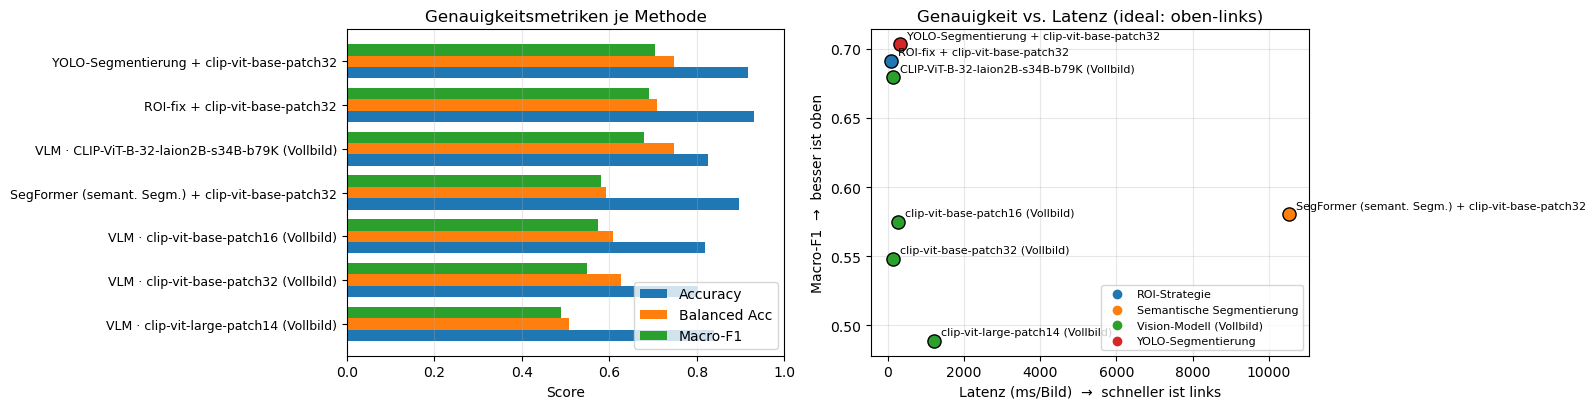

In [18]:
if RESULTS:
    ordered = sorted(RESULTS, key=lambda r: r["macro_f1"], reverse=True)
    names = [r["method"] for r in ordered]
    y = np.arange(len(names))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, max(4, 0.6 * len(names))))

    # Links: gruppierte Balken (Accuracy / Balanced Acc / Macro-F1)
    bar_h = 0.26
    ax1.barh(y + bar_h, [r["accuracy"] for r in ordered], bar_h, label="Accuracy")
    ax1.barh(y, [r["balanced_accuracy"] for r in ordered], bar_h, label="Balanced Acc")
    ax1.barh(y - bar_h, [r["macro_f1"] for r in ordered], bar_h, label="Macro-F1")
    ax1.set_yticks(y)
    ax1.set_yticklabels(names, fontsize=9)
    ax1.invert_yaxis()
    ax1.set_xlabel("Score")
    ax1.set_xlim(0, 1)
    ax1.set_title("Genauigkeitsmetriken je Methode")
    ax1.legend(loc="lower right")
    ax1.grid(axis="x", alpha=0.3)

    # Rechts: Accuracy-vs-Latenz-Streudiagramm
    cats = sorted({r["category"] for r in ordered})
    cmap = plt.get_cmap("tab10")
    color_of = {c: cmap(i) for i, c in enumerate(cats)}
    for r in ordered:
        ax2.scatter(r["latency_mean_ms"], r["macro_f1"],
                    s=90, color=color_of[r["category"]], edgecolor="black", zorder=3)
        ax2.annotate(r["method"].split(" · ")[-1], (r["latency_mean_ms"], r["macro_f1"]),
                     fontsize=8, xytext=(5, 4), textcoords="offset points")
    for c in cats:
        ax2.scatter([], [], color=color_of[c], label=c)
    ax2.set_xlabel("Latenz (ms/Bild)  →  schneller ist links")
    ax2.set_ylabel("Macro-F1  →  besser ist oben")
    ax2.set_title("Genauigkeit vs. Latenz (ideal: oben-links)")
    ax2.grid(alpha=0.3)
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


## 10. Konfusionsmatrizen & klassenweise Auswertung

Für die **beste Methode je Kategorie** (nach Macro-F1) zeigen wir die Konfusionsmatrix. Sie
offenbart typische Verwechslungen (z. B. Schotter ↔ Erde) und ob seltene Klassen überhaupt
erkannt werden – Information, die Accuracy allein verbirgt.


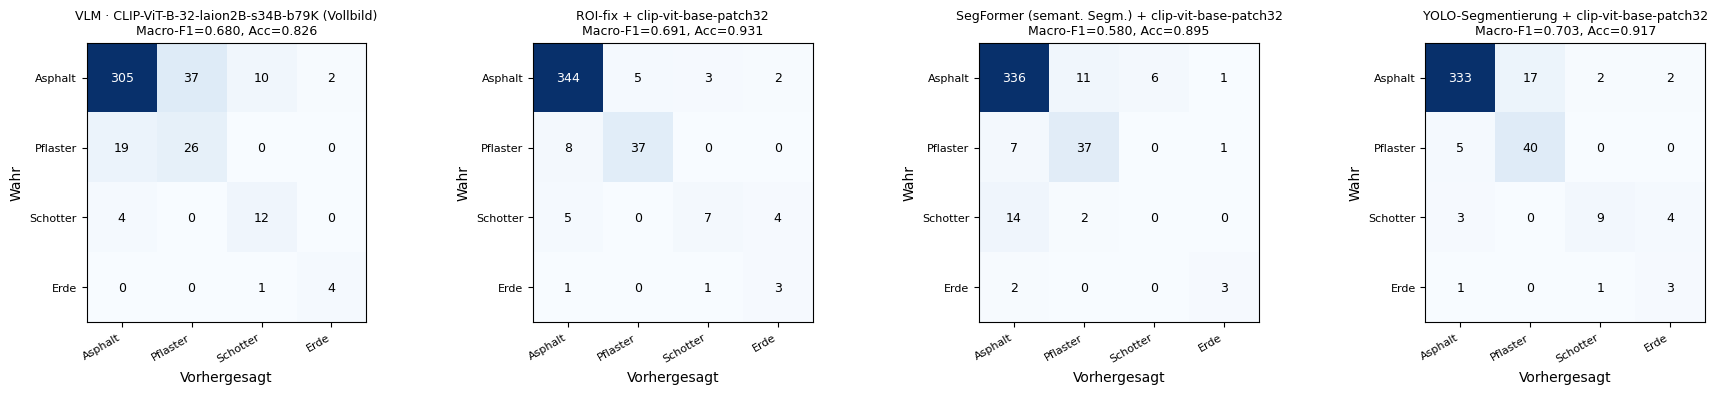

Beste Methode (Macro-F1): YOLO-Segmentierung + clip-vit-base-patch32

Klasse                       Precision   Recall     F1  Support
Asphalt/Beton                    0.974    0.941  0.957      354
Pflaster/Kopfsteinpflaster       0.702    0.889  0.784       45
Schotter/Kies                    0.750    0.562  0.643       16
Erde/Feldweg                     0.333    0.600  0.429        5


In [19]:
def plot_confusion(ax, cm: np.ndarray, classes: list[str], title: str) -> None:
    """Zeichnet eine Konfusionsmatrix (Zeilen = wahr, Spalten = vorhergesagt)."""
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    short = [c.split("/")[0] for c in classes]
    ax.set_xticklabels(short, rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(short, fontsize=8)
    ax.set_xlabel("Vorhergesagt")
    ax.set_ylabel("Wahr")
    ax.set_title(title, fontsize=9)
    thresh = cm.max() / 2 if cm.max() else 0
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black", fontsize=9)


if RESULTS:
    # Beste Methode je Kategorie nach Macro-F1
    best_per_cat: dict[str, dict] = {}
    for r in RESULTS:
        cat = r["category"]
        if cat not in best_per_cat or r["macro_f1"] > best_per_cat[cat]["macro_f1"]:
            best_per_cat[cat] = r

    best = list(best_per_cat.values())
    n = len(best)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, r in zip(axes, best):
        plot_confusion(ax, r["confusion"], EVAL_CLASSES,
                       f"{r['method']}\nMacro-F1={r['macro_f1']:.3f}, Acc={r['accuracy']:.3f}")
    plt.tight_layout()
    plt.show()

    # Klassenweise Kennzahlen der insgesamt besten Methode
    overall_best = max(RESULTS, key=lambda r: r["macro_f1"])
    print(f"Beste Methode (Macro-F1): {overall_best['method']}\n")
    print(f"{'Klasse':<28}{'Precision':>10}{'Recall':>9}{'F1':>7}{'Support':>9}")
    for cls in EVAL_CLASSES:
        pc = overall_best["per_class"][cls]
        print(f"{cls:<28}{pc['precision']:>10.3f}{pc['recall']:>9.3f}"
              f"{pc['f1']:>7.3f}{pc['support']:>9}")


## 11. Fazit & Empfehlung

Die folgende Zelle leitet aus den Ergebnissen automatisch eine Empfehlung ab: das **genaueste**
Verfahren (höchste Macro-F1), das **schnellste** sowie den besten **Kompromiss** (Effizienz =
Macro-F1 pro ms). Für den Bikeability-Score (Feature $O_{surf}$, viele Frames pro Strecke) zählt
der Kompromiss aus Genauigkeit und Latenz besonders.


In [21]:
if not RESULTS:
    print("Keine Ergebnisse vorhanden – bitte die Benchmark-Zellen ausführen.")
else:
    best_acc = max(RESULTS, key=lambda r: r["macro_f1"])
    fastest = min(RESULTS, key=lambda r: r["latency_mean_ms"])
    # Effizienz: Macro-F1 pro ms (höher = besserer Kompromiss)
    best_tradeoff = max(RESULTS, key=lambda r: r["macro_f1"] / max(r["latency_mean_ms"], 1e-6))

    print("=" * 70)
    print("EMPFEHLUNG – Fahrbahnoberflächen-Erkennung")
    print("=" * 70)
    print(f"Evaluationsmenge: {len(EVAL_ITEMS)} Bilder · Device: {DEVICE}\n")

    print(f"🏆 Höchste Genauigkeit : {best_acc['method']}")
    print(f"    Macro-F1={best_acc['macro_f1']:.3f} · Balanced Acc={best_acc['balanced_accuracy']:.3f}"
          f" · Accuracy={best_acc['accuracy']:.3f} · {best_acc['latency_mean_ms']:.1f} ms/Bild\n")

    print(f"⚡ Schnellste Methode   : {fastest['method']}")
    print(f"    {fastest['latency_mean_ms']:.1f} ms/Bild ({fastest['throughput_ips']:.1f} Bilder/s)"
          f" · Macro-F1={fastest['macro_f1']:.3f}\n")

    print(f"⚖ Bester Kompromiss    : {best_tradeoff['method']}")
    print(f"    Macro-F1={best_tradeoff['macro_f1']:.3f} · {best_tradeoff['latency_mean_ms']:.1f} ms/Bild\n")

    # Bringt Segmentierung als Vorverarbeitung etwas gegenüber Vollbild (gleiches VLM)?
    rep_results = {r["category"]: r for r in RESULTS
                   if short_rep in r["method"]}
    baseline = next((r for r in RESULTS
                     if r["method"] == f"VLM · {short_rep} (Vollbild)"), None)
    if baseline:
        print("Effekt der Vorverarbeitung (gleiches VLM, Δ Macro-F1 ggü. Vollbild):")
        for cat, r in rep_results.items():
            if r is baseline:
                continue
            delta = r["macro_f1"] - baseline["macro_f1"]
            extra = r["latency_mean_ms"] - baseline["latency_mean_ms"]
            sign = "+" if delta >= 0 else ""
            print(f"  {r['method']:<44} {sign}{delta:.3f}  ({extra:+.1f} ms/Bild)")
    print("=" * 70)


EMPFEHLUNG – Fahrbahnoberflächen-Erkennung
Evaluationsmenge: 420 Bilder · Device: cpu

🏆 Höchste Genauigkeit : YOLO-Segmentierung + clip-vit-base-patch32
    Macro-F1=0.703 · Balanced Acc=0.748 · Accuracy=0.917 · 312.0 ms/Bild

⚡ Schnellste Methode   : ROI-fix + clip-vit-base-patch32
    79.4 ms/Bild (12.6 Bilder/s) · Macro-F1=0.691

⚖ Bester Kompromiss    : ROI-fix + clip-vit-base-patch32
    Macro-F1=0.691 · 79.4 ms/Bild

Effekt der Vorverarbeitung (gleiches VLM, Δ Macro-F1 ggü. Vollbild):
  ROI-fix + clip-vit-base-patch32              +0.143  (-48.8 ms/Bild)
  SegFormer (semant. Segm.) + clip-vit-base-patch32 +0.032  (+10394.0 ms/Bild)
  YOLO-Segmentierung + clip-vit-base-patch32   +0.155  (+183.8 ms/Bild)
